In [20]:
import json
import pandas as pd
from sklearn.decomposition import NMF
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
with open('../data/song_emotion_wheel_data.llm.json', 'r') as f:
    data = json.load(f)

In [6]:
df = pd.json_normalize(data)

In [7]:
emotion_cols = [
    'emotion_scores_mean.joy',
    'emotion_scores_mean.trust',
    'emotion_scores_mean.fear',
    'emotion_scores_mean.surprise',
    'emotion_scores_mean.sadness',
    'emotion_scores_mean.disgust',
    'emotion_scores_mean.anger',
    'emotion_scores_mean.anticipation'
]

In [8]:
X = df[emotion_cols].fillna(0)

In [46]:
n_themes = 4

In [47]:
nmf = NMF(n_components=n_themes, init='nndsvda', random_state=42, max_iter=1000)
song_theme_matrix = nmf.fit_transform(X)

theme_emotion_matrix = nmf.components_
theme_emotion_matrix

array([[0.        , 0.        , 0.1073473 , 0.        , 5.24921374,
        0.        , 0.4296096 , 0.14802703],
       [2.395252  , 1.2665801 , 0.        , 0.36924675, 0.16756016,
        0.        , 0.        , 1.29646506],
       [0.01268323, 0.        , 0.1839944 , 0.22699959, 0.22432176,
        0.71700773, 1.84527393, 0.20989062],
       [0.        , 0.38088818, 1.48825025, 0.56336849, 0.47972557,
        0.01938475, 0.        , 0.95442431]])

In [48]:
song_theme_percentages = normalize(song_theme_matrix, norm='l1', axis=1)

theme_names = ["theme_"+str(i+1) for i in range(n_themes)]
df_percentages = pd.DataFrame(song_theme_percentages, columns=theme_names)

df_final = pd.concat([df[['song_title', 'album']], df_percentages], axis=1)

print(df_final.head())

               song_title         album   theme_1   theme_2   theme_3  \
0              Tim McGraw  Taylor Swift  0.380704  0.574736  0.044560   
1         Picture To Burn  Taylor Swift  0.149789  0.024240  0.825971   
2  Teardrops On My Guitar  Taylor Swift  0.429298  0.289243  0.011556   
3   A Place In This World  Taylor Swift  0.266971  0.360384  0.000000   
4             Cold As You  Taylor Swift  0.443146  0.000000  0.556854   

    theme_4  
0  0.000000  
1  0.000000  
2  0.269903  
3  0.372645  
4  0.000000  


In [49]:
clean_emotions = [col.split('.')[-1].capitalize() for col in emotion_cols]
theme_names = ["theme_" + str(i+1) for i in range(n_themes)]

<Axes: >

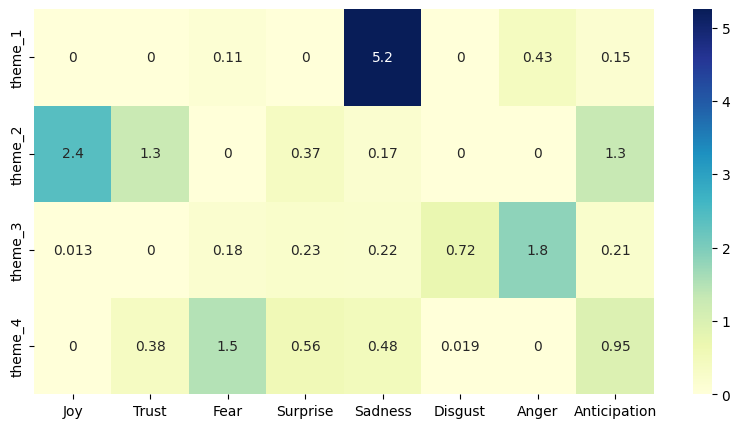

In [50]:

plt.figure(figsize=(10, 5))
sns.heatmap(nmf.components_, annot=True, cmap="YlGnBu", xticklabels=clean_emotions, yticklabels=theme_names)

In [51]:
clean_emotions = [col.split('.')[-1].capitalize() for col in emotion_cols]
df_matrix = pd.DataFrame(nmf.components_, columns=clean_emotions, index=theme_names)

print(df_matrix.round(3).to_markdown())

|         |   Joy |   Trust |   Fear |   Surprise |   Sadness |   Disgust |   Anger |   Anticipation |
|:--------|------:|--------:|-------:|-----------:|----------:|----------:|--------:|---------------:|
| theme_1 | 0     |   0     |  0.107 |      0     |     5.249 |     0     |   0.43  |          0.148 |
| theme_2 | 2.395 |   1.267 |  0     |      0.369 |     0.168 |     0     |   0     |          1.296 |
| theme_3 | 0.013 |   0     |  0.184 |      0.227 |     0.224 |     0.717 |   1.845 |          0.21  |
| theme_4 | 0     |   0.381 |  1.488 |      0.563 |     0.48  |     0.019 |   0     |          0.954 |


In [53]:
labels = ["Heartbreak", "Romantic optimism", "Vengeance", "Anxiety"]

for i, song in enumerate(data):
    song['theme_scores'] = {
        labels[j]: round(float(song_theme_percentages[i][j]), 3)
        for j in range(n_themes)
    }

# with open('song_themes_processed.json', 'w', encoding='utf-8') as f:
with open('processed_lyrical_themes.llm.json', 'w', encoding='utf-8') as f:
    json.dump(data, f)